In [1]:
# 必要なモジュールをインポート
import os
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI

# 環境変数の読み込み
load_dotenv("../.env")
os.environ['OPENAI_API_KEY'] = os.environ['API_KEY']

# モデル名
MODEL_NAME = "gpt-4o-mini"

In [2]:
# 検索ツールの定義
from langchain_community.tools.tavily_search import TavilySearchResults

tool = TavilySearchResults(max_results=2)
tools = [tool]

In [3]:
tool.invoke("Langgraphのノードとは？")

[{'url': 'https://www.creationline.com/tech-blog/author/higuchi/75504',
  'content': 'また、次の記事を参考にさせていただきました。\n\n## 「ノード」と「エッジ」\n\nまず「グラフ」という概念において、点である「ノード」と線である「エッジ」という構成要素を押さえておく必要がありそうです。LangGraphにおいても、処理を担当する「ノード」と処理同士を接続する「エッジ」という、次のような図になりそうです。\n\n## ２つのノードを接続する\n\n`value`\n`1`\n`node1`\n`value`\n`2`\n`node2`\n\nと２つのノードがあり、\n\n`node1`\n`node2`\n\nというエッジで２つのノードを接続するとします。また、\n\n`node1`\n`node2`\n\nという流れとします。ここで `value` の初期値を `0` として開始するLangGraphスクリプトを書いてみました。\n\n`value`\n`0`\n\nこのような形になります。 `add_node` と `add_edge` の字面が似ているので並んでいると目が滑るのですが…。コメントを入れたり、LangGraphの理解が進めば見分けがつくようになってくるかなと思います。また、LLM関係のコードを含めず、純粋にLangGraphのみのコードになっているので、まだ何をやっているか分かりやすいはずです。\n\n`add_node`\n`add_edge`\n\nこれを実行すると次のようになります。\n\n`value` が `0` で開始し、 `2` となって終わりました。途中の `1` となっているところが見えませんが、スクリプトの最終行を、\n\n`value`\n`0`\n`2`\n`1`\n\nとすることでデバッグ出力が有効となり、次のように途中経過もわかるようになります。\n\n## グラフの条件分岐\n\nグラフに条件分岐を作ります。特に注目するところだけにコメントをつけていきます。'},
 {'url': 'https://www.ibm.com/think/topics/langgraph',
  'content': 'Nodes: In Lan

In [4]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph
from langgraph.graph.message import add_messages

# Stateクラスの定義
class State(TypedDict):
    messages: Annotated[list, add_messages]

# グラフのインスタンスを作成
graph_builder = StateGraph(State)

# 言語モデルの定義
llm = ChatOpenAI(model_name=MODEL_NAME)

# 変更点：ツール定義の紐づけ
llm_with_tools = llm.bind_tools(tools)

# チャットボットノードの作成
def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

# グラフにチャットボットノードを追加
graph_builder.add_node("chatbot", chatbot)


In [5]:
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver

# ツールノードの作成
tool_node = ToolNode(tools)

# グラフにツールノードを追加
graph_builder.add_node("tools", tool_node)

# 条件付エッジの作成
graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition, # ツール呼出と判断したらツールノードを呼ぶ
)

# ツールが呼び出されるたびに、チャットボットに戻って次のステップを決定
# ツールからチャットボットへの戻りエッジを作成
graph_builder.add_edge("tools", "chatbot")

# 開始ノードの指定
graph_builder.set_entry_point("chatbot")

# 記憶を持つ実行可能なステートグラフの作成
memory = MemorySaver()
graph = graph_builder.compile(checkpointer=memory)

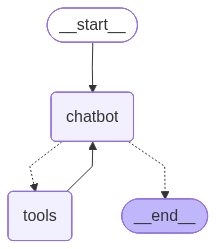

In [6]:
# グラフの可視化
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [7]:
# グラフの実行と結果の表示
def stream_graph_updates(user_input: str):
    events = graph.stream(
        {"messages": [("user", user_input)]},
        {"configurable": {"thread_id": "1"}},
        stream_mode="values")
    # 結果をストリーミングで得る
    for event in events:
        print(event["messages"][-1].content, flush=True)

# チャットボットのループ
while True:
    user_input = input("質問:")
    if user_input.strip()=="":
        print("ありがとうございました!")
        break
    stream_graph_updates(user_input)

こんにちは
こんにちは！今日はどのようなことをお手伝いできますか？
1たす1は？
1たす1は2です。何か他に知りたいことがありますか？
1メートル以上の魚は？

[{"url": "https://www.kuromon.jp/blog/industry/1018/", "content": "鮮魚川崎について\n 川崎ブログ\n ご注文方法\n\n HOME\n 鮮魚川崎について\n 川崎ブログ\n ご注文方法\n お問い合わせ\n プライバシーポリシー\n\n HOME >\n 業界情報 >\n 1m超える新種の深海魚「ヨコヅナイワシ」発見 静岡沖 駿河湾\n\n業界情報\n\n## 1m超える新種の深海魚「ヨコヅナイワシ」発見 静岡沖 駿河湾\n\n静岡県沖の駿河湾で、体長1メートルを超える大型の新種の深海魚が見つかり、「ヨコヅナイワシ」と名付けられました。発見したグループは「これほど大型の魚が見つからずにいたのは珍しい」としています。\n\n海洋研究開発機構の研究グループは、2016年に静岡県沖の駿河湾の深海で生物の調査を行ったところ、水深2000メートル余りでこれまで知られていない大型の深海魚を4匹捕獲しました。\n\n4匹は、いずれも体長が1メートルを超えていて、最も大きいものは1メートル30センチ余り、重さはおよそ25キロあったということです。\n\n形態や遺伝子の解析から、「セキトリイワシ」という深海魚の仲間の新種で、この仲間の中では最も大きいことから、研究グループは「ヨコヅナイワシ」と名付けました。\n\n「ヨコヅナイワシ」のうろこは鮮やかな青色で、胃の内容物や食物連鎖の中での位置を調べる最新の分析方法から、駿河湾の深海の食物連鎖の最上位に位置することが分かったということです。\n\nまた、研究グループは、深海に設置したカメラで、1メートルを超える「ヨコヅナイワシ」が、海底付近をゆっくりと泳ぐ姿の撮影にも成功しています。\n\n海洋研究開発機構の藤原義弘上席研究員は「大型の魚が見つからずにいたのは珍しい。深海には私たちの知らない生物の多様性があり、深海での漁業も増えているので、生態系を崩さないよう注意が必要だ」と話していました。\n\n## 「ヨコヅナイワシ」の特徴 [...] 最近の魚達\n\n### 初サンマ、キロ12万円の最高値　不漁で入荷わ